# 03 - Optimization Space

## What selects one solution?

Notebook 00 introduced the workshop frame:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s.
$$

Notebook 01 unpacked $\mathcal{D}$ as finite evidence. Notebook 02 unpacked $\mathcal{H}$ as the set of explanations the learner is allowed to consider. That left an important gap: a hypothesis space can contain many candidates, and the data do not choose among them by themselves.

This notebook turns to the boxed term:

$$
\mathcal{H}+\mathcal{D}+\boxed{\mathcal{O}}\rightarrow s.
$$

Here $\mathcal{O}$ means the selection machinery: the losses, penalties, numerical solvers, and rules used to compare candidate parameter values and return one selected solution. In this notebook, the selected solution is a fitted parameter vector $\hat{\theta}$ and the corresponding function $h_{\hat{\theta}}$.

The through-line is:

1. keep $\mathcal{D}$ and $\mathcal{H}$ fixed;
2. give each candidate hypothesis a score on the observed data;
3. minimise that score to select one $s$;
4. read least squares as a geometric selection rule;
5. change $\mathcal{O}$ by adding a penalty;
6. vary the penalty and watch the selected $s$ move inside the same $\mathcal{H}$;
7. hand the trust and generalisation question to Notebook 04.

Polynomial regression is a useful first case because the model is linear in $\theta$. Squared-error objectives become quadratic surfaces, so least squares and ridge have closed-form solutions. That lets us see the selection machinery before moving to models where $\mathcal{O}$ is usually iterative and less transparent in future workshops.

## Learning objectives

By the end of this notebook, you should be able to:

1. explain why $\mathcal{D}$ and $\mathcal{H}$ do not select a solution by themselves;
2. define a loss as a rule for scoring candidate hypotheses;
3. explain least squares as a selector inside a fixed hypothesis space;
4. distinguish the objective from the numerical solver;
5. explain how adding a ridge penalty changes the selected solution without changing the raw hypothesis space;
6. connect ridge regularisation to MAP estimation at a high level.

## Session arc

This notebook follows one semantic wave:

1. **Abstract:** $\mathcal{O}$ is the machinery that selects one solution.
2. **Concrete:** score candidate lines by squared error.
3. **Inspect:** draw the loss landscape and locate the selected point.
4. **Deepen:** derive least squares and distinguish selector from solver.
5. **Intervene:** add ridge regularisation and vary $\lambda$.
6. **Repack:** changing $\mathcal{O}$ changes which member of $\mathcal{H}$ becomes $s$.

Use this question throughout:

> What did the optimizer reward, and what kind of solution did that reward select?

In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


## Start From Fixed $\mathcal{D}$ and $\mathcal{H}$

Begin exactly where Notebook 02 ended. We have one collected dataset,

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n},
$$

and we have chosen a polynomial hypothesis space $\mathcal{H}$ as the family of explanations we are willing to consider. Those choices define the evidence and the menu of possible functions. They still do not choose a fitted model.

A degree-15 polynomial space, for example, contains many curves with very different behaviour between observed points. The question for this notebook is:

> Given fixed evidence $\mathcal{D}$ and a fixed hypothesis space $\mathcal{H}$, what rule selects one parameter vector $\hat{\theta}$?

For the first pass, do not introduce train/test reasoning. The selector only sees the observed evidence $\mathcal{D}$. Notebook 04 will ask whether the selected function should be trusted away from the evidence used to select it.

In [2]:
# Reuse the same evidence controls as Notebook 02.
n_samples = 20
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

# Keep these aliases so later cells read as optimisation over the fitting data.
x_train_opt = x_observed
y_train_opt = y_observed

print_rows(
    [
        {
            "n_samples": n_samples,
            "noise_std": noise_std,
            "sampling": sampling,
            "x_min": np.min(x_train_opt),
            "x_max": np.max(x_train_opt),
        }
    ],
    title="Same fixed evidence as Notebook 02",
)


Same fixed evidence as Notebook 02
01. n_samples=20, noise_std=0.2000, sampling=uniform, x_min=0.1774, x_max=0.9670


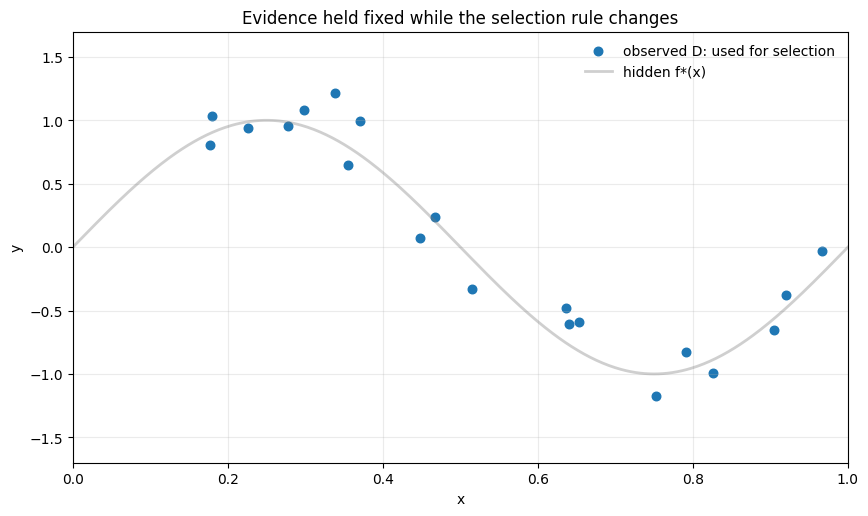

In [3]:
# Visualise the fixed evidence used by the optimizer.
x_grid = data.make_test_grid(n_points=500)
fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.scatter(x_train_opt, y_train_opt, s=38, color="#1f77b4", label="observed D: used for selection")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax.set_title("Evidence held fixed while the selection rule changes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


## Give Each Candidate a Score

A selection rule first needs a way to compare candidates. Start with the degree-1 hypothesis space:

$$
h_\theta(x) = \theta_0 + \theta_1x.
$$

Every point $(\theta_0, \theta_1)$ describes a different line. To score one candidate, make predictions on the observed evidence, compute residuals, and reduce those residuals to one number.

One common score is mean squared error:

$$
\mathcal{L}_{\mathcal{D}}(\theta) = \frac{1}{n}\sum_{(x_i,y_i)\in\mathcal{D}} (y_i - h_\theta(x_i))^2.
$$

Smaller values mean the candidate fits the observed data better under this particular scoring rule. The score is not the model and it is not the truth; it is the criterion $\mathcal{O}$ will use to compare candidates.

The next cell scores a few hand-written lines before any optimiser is allowed to choose. This makes the separation visible: $\mathcal{H}$ supplies the candidate lines, $\mathcal{D}$ supplies the residuals, and $\mathcal{O}$ supplies the score.

### Before running: score is not truth

The next cell scores several hand-written candidate lines. The score is not the model and it is not the truth. It is a rule for comparing candidates.

Before running, predict which candidate will have the smallest MSE and which will miss the data most badly.


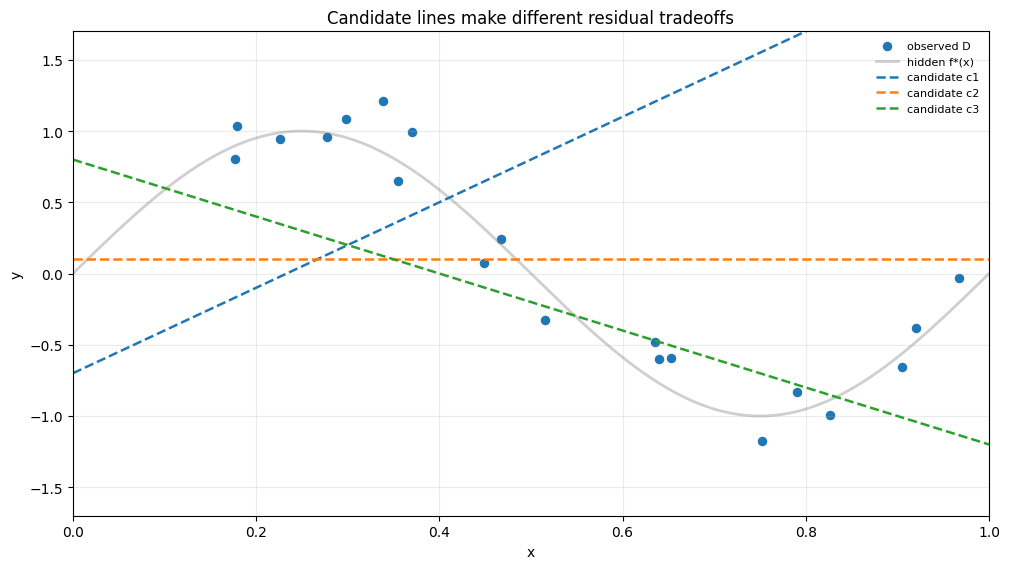

Candidate degree-1 theta values
01. candidate=c1, theta_0=-0.7000, theta_1=3.0000, train_mse=2.8495, mean_abs_residual=1.4763, max_abs_residual=2.7699
02. candidate=c2, theta_0=0.1000, theta_1=0, train_mse=0.6068, mean_abs_residual=0.7056, max_abs_residual=1.2770
03. candidate=c3, theta_0=0.8000, theta_1=-2.0000, train_mse=0.3356, mean_abs_residual=0.4682, max_abs_residual=1.1032


In [4]:
# Score a few candidate lines before asking an optimizer to choose.
candidate_thetas = [(-0.7, 3.0), (0.1, 0.0), (0.8, -2.0)]
candidate_rows = []

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_opt, y_train_opt, s=34, color="#1f77b4", label="observed D")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")

for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    train_pred = theta0 + theta1 * x_train_opt
    grid_pred = theta0 + theta1 * x_grid
    residuals = y_train_opt - train_pred
    candidate_rows.append(
        {
            "candidate": f"c{idx}",
            "theta_0": theta0,
            "theta_1": theta1,
            "train_mse": metrics.mse(y_train_opt, train_pred),
            "mean_abs_residual": np.mean(np.abs(residuals)),
            "max_abs_residual": np.max(np.abs(residuals)),
        }
    )
    ax.plot(x_grid, grid_pred, linestyle="--", linewidth=1.8, label=f"candidate c{idx}")

ax.set_title("Candidate lines make different residual tradeoffs")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
show_fig(fig)
print_rows(candidate_rows, title="Candidate degree-1 theta values")


### After running: read the score as selection pressure

Inspect the residuals and the MSE table.

- Which candidate looked best under this score?
- Would a different loss value the same errors differently?
- Did we change $\mathcal{H}$, $\mathcal{D}$, or only the way candidates were scored?

**Repack.** A loss function turns model fitting into a comparison problem. It defines what kind of mistake the optimizer cares about.

## Turn Scores Into a Selector

Scoring candidates is not yet learning. The selection step chooses the parameter value with the smallest score.

For least squares, the selector is:

$$
\mathcal{O}_{\mathrm{LS}}(\mathcal{D}) = \operatorname*{arg\,min}_{\theta\in\Theta}\,\mathcal{L}_{\mathcal{D}}(\theta).
$$

For a two-parameter line, we can draw the score assigned to each possible $\theta$. With a full-rank degree-1 design matrix, the surface is a strict convex quadratic bowl with one selected point. If the design matrix is rank deficient, least squares remains convex, but flat directions can make the selected $\theta$ non-unique.

The hand-written `candidate_thetas` are only reference points on this surface. Least squares is not choosing the best one from that short list; it is searching the full parameter space $\Theta$ for the lowest score.

### Before running: from scoring to selecting

Scoring a few hand-written candidates is not yet optimization. Least squares searches the whole parameter space for the lowest score.

Before running, predict where the bottom of the bowl will sit relative to the hand-written candidates. Then ask:

> If we removed one hand-written candidate from the display, would the least-squares solution move? Why or why not?

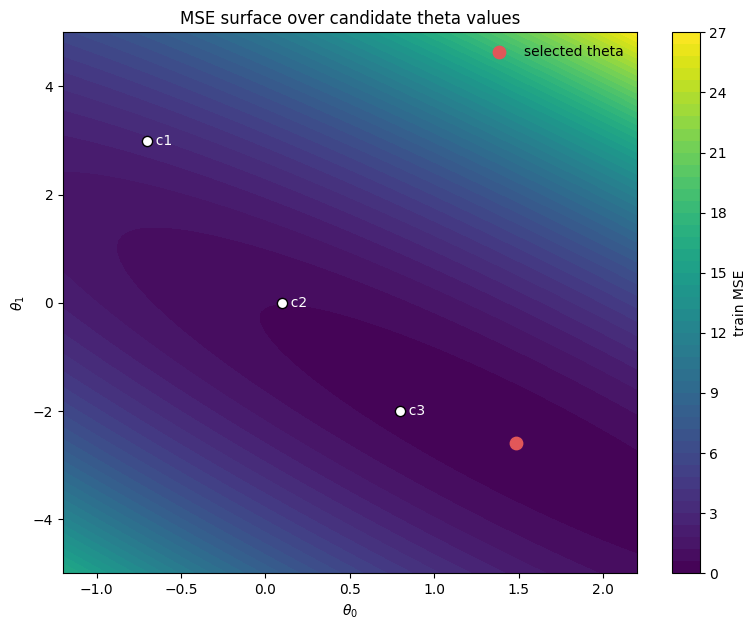

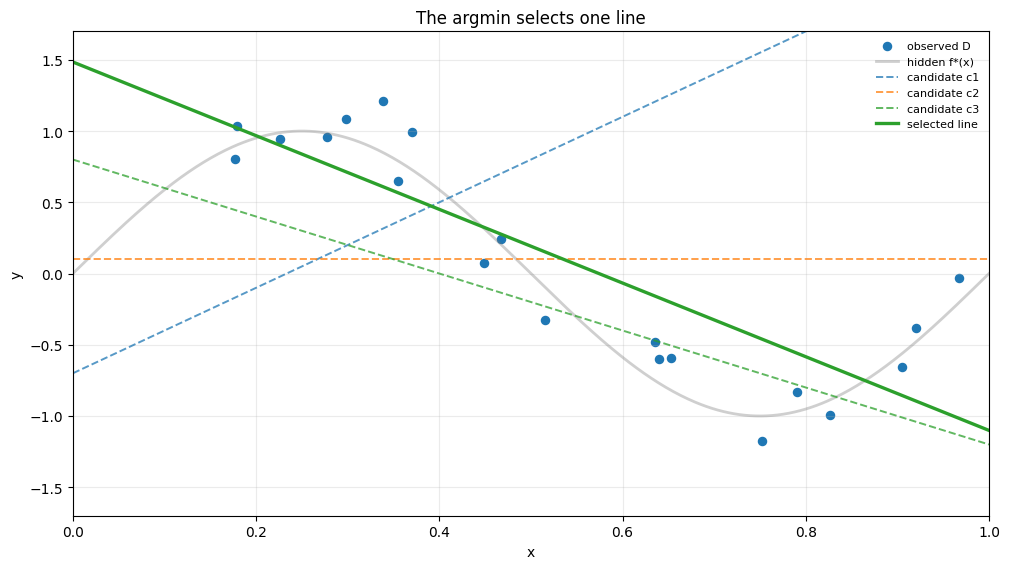

Theta selected by least squares
01. theta_0=1.4847, theta_1=-2.5859, train_mse=0.1767


In [5]:
# Draw the degree-1 loss surface and the theta selected by least squares.
theta0_values = np.linspace(-1.2, 2.2, 100)
theta1_values = np.linspace(-5.0, 5.0, 100)
Theta0, Theta1 = np.meshgrid(theta0_values, theta1_values)

loss_surface = np.empty_like(Theta0)
for row in range(Theta0.shape[0]):
    for col in range(Theta0.shape[1]):
        pred = Theta0[row, col] + Theta1[row, col] * x_train_opt
        loss_surface[row, col] = metrics.mse(y_train_opt, pred)

coeffs_line = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=1)
selected_line = models.predict_polynomial(x_grid, coeffs_line)
selected_train_mse = metrics.mse(y_train_opt, models.predict_polynomial(x_train_opt, coeffs_line))

fig_loss, ax_loss = plt.subplots(figsize=(8.0, 6.4))
contour = ax_loss.contourf(Theta0, Theta1, loss_surface, levels=50, cmap="viridis")
for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    ax_loss.scatter(theta0, theta1, color="white", edgecolor="black", s=54)
    ax_loss.text(theta0, theta1, f"  c{idx}", color="white", va="center")
ax_loss.scatter(coeffs_line[0], coeffs_line[1], color="#e15759", s=80, label="selected theta")
ax_loss.set_title("MSE surface over candidate theta values")
ax_loss.set_xlabel(r"$\theta_0$")
ax_loss.set_ylabel(r"$\theta_1$")
ax_loss.legend(frameon=False)
fig_loss.colorbar(contour, ax=ax_loss, label="train MSE")
fig_loss.tight_layout()
show_fig(fig_loss)

fig_curve, ax_curve = plt.subplots(figsize=(10.2, 5.8))
ax_curve.scatter(x_train_opt, y_train_opt, s=34, color="#1f77b4", label="observed D")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    ax_curve.plot(x_grid, theta0 + theta1 * x_grid, linestyle="--", linewidth=1.4, alpha=0.75, label=f"candidate c{idx}")
ax_curve.plot(x_grid, selected_line, color="#2ca02c", linewidth=2.4, label="selected line")
ax_curve.set_title("The argmin selects one line")
ax_curve.set_xlabel("x")
ax_curve.set_ylabel("y")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-1.7, 1.7)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8)
fig_curve.tight_layout()
show_fig(fig_curve)

print_rows(
    [{"theta_0": coeffs_line[0], "theta_1": coeffs_line[1], "train_mse": selected_train_mse}],
    title="Theta selected by least squares",
)


### After running: interpret the loss landscape

Read the contour plot before reading the equations.

- Every point in the landscape is one parameter vector.
- The height or colour is the loss assigned by $\mathcal{O}$.
- The selected point is the bottom of the bowl.

**Repack.** The optimizer is not choosing from the few examples we drew. It is selecting the lowest-scoring point in the available parameter space.

### Mathematical unpacking: why the bowl has a selected point

The contour plot gave the visual story. The equations explain the bottom of the least-squares bowl: at the selected point, no small change to the parameters reduces the squared-error score.

Stack the feature rows for the observed data into a design matrix $\Phi$. The prediction vector is $\hat{y}=\Phi\theta$, and the residual vector is:

$$
r(\theta)=\Phi\theta-y.
$$

Use residual sum of squares for the algebra:

$$
\mathcal{L}_{\mathcal{D}}(\theta)=\lVert \Phi\theta-y\rVert_2^2.
$$

This selects the same $\hat{\theta}$ as MSE because dividing the whole objective by $n$ does not change which value is smallest.

For this quadratic objective, the slope with respect to the parameters is:

$$
\nabla_\theta \mathcal{L}_{\mathcal{D}}(\theta)=2\Phi^\top(\Phi\theta-y).
$$

Setting that slope to zero gives the **normal equations**:

$$
\Phi^\top\Phi\theta=\Phi^\top y.
$$

If the columns of $\Phi$ are independent, $\Phi^\top\Phi$ is invertible, so there is one least-squares selector:

$$
\hat{\theta}=(\Phi^\top\Phi)^{-1}\Phi^\top y.
$$

In plain English: least squares keeps adjusting the line until no small change to the intercept or slope would reduce the squared errors. The selected line is not necessarily scientifically true; it is the line that best satisfies this particular score on this particular dataset.

## Check What Least Squares Selected

The previous picture used a grid because there were only two parameters. For a larger polynomial space, drawing every possible $\theta$ is no longer practical, but the same objects are still present.

For a polynomial basis, collect all feature rows from $\mathcal{D}$ into a design matrix $\Phi$:

$$
\Phi = \begin{bmatrix}
\phi(x_1)^\top \\
\phi(x_2)^\top \\
\vdots \\
\phi(x_n)^\top
\end{bmatrix}.
$$

Each row belongs to one observation. Each column is one reusable feature shape from Notebook 02: $1$, $x$, $x^2$, and so on. The parameter vector $\theta$ mixes those columns, producing all training predictions at once:

$$
\hat{y}=\Phi\theta.
$$

The least-squares condition

$$
\Phi^\top(\Phi\hat{\theta}-y)=0
$$

says that every feature column has zero dot product with the final residual vector. In plainer language: after fitting, none of the available feature shapes can explain a remaining one-step pattern in the errors.

Another way to say this: if the residuals still lined up with the column $x^2$, then adding a little more $x^2$ would improve the fit. At the least-squares solution, every available column has already been used as much as this score can justify.

The next cells check that story numerically and visually for a degree-3 polynomial. The table compares the normal-equation solution with the stable numerical least-squares helper, then prints the feature-residual dot products that should be near zero. The plot turns those near-zero dot products into a diagnostic picture.

Read this as a check on $\mathcal{O}$: did the least-squares selector reach the point it intended to select? This is not a new data choice and not a new hypothesis-space choice.


In [6]:
# Compare the normal-equation view with the numerical least-squares helper.
closed_degree = 3
Phi = models.polynomial_features(x_train_opt, degree=closed_degree)
gram_matrix = Phi.T @ Phi
rhs_vector = Phi.T @ y_train_opt

coeffs_normal = np.linalg.solve(gram_matrix, rhs_vector)
coeffs_lstsq = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=closed_degree)
max_abs_difference = np.max(np.abs(coeffs_normal - coeffs_lstsq))
residuals_lstsq = Phi @ coeffs_lstsq - y_train_opt
feature_residual_dots = Phi.T @ residuals_lstsq

print_rows(
    [
        {"object": "Phi", "shape": Phi.shape},
        {"object": "rank(Phi)", "value": np.linalg.matrix_rank(Phi)},
        {"object": "cond(Phi)", "value": np.linalg.cond(Phi)},
        {"object": "cond(Phi.T @ Phi)", "value": np.linalg.cond(gram_matrix)},
        {"object": "max_abs_difference", "value": max_abs_difference},
        {"object": "max_abs_feature_residual_dot", "value": np.max(np.abs(feature_residual_dots))},
        {"object": "residual_norm", "value": np.linalg.norm(residuals_lstsq)},
    ],
    title="Closed-form least-squares mechanics",
)
print_rows(
    [{"feature": f"x^{idx}", "theta": value, "feature_dot_residual": feature_residual_dots[idx]} for idx, value in enumerate(coeffs_lstsq)],
    title=f"Selected degree-{closed_degree} theta values and stationarity check",
)

Closed-form least-squares mechanics
01. object=Phi, shape=(20, 4)
02. object=rank(Phi), value=4
03. object=cond(Phi), value=236.1409
04. object=cond(Phi.T @ Phi), value=5.58e+04
05. object=max_abs_difference, value=2.62e-11
06. object=max_abs_feature_residual_dot, value=3.26e-14
07. object=residual_norm, value=0.7564
Selected degree-3 theta values and stationarity check
01. feature=x^0, theta=-0.6495, feature_dot_residual=3.26e-14
02. feature=x^1, theta=15.4429, feature_dot_residual=2.98e-14
03. feature=x^2, theta=-41.5943, feature_dot_residual=2.47e-14
04. feature=x^3, theta=27.2079, feature_dot_residual=2.06e-14


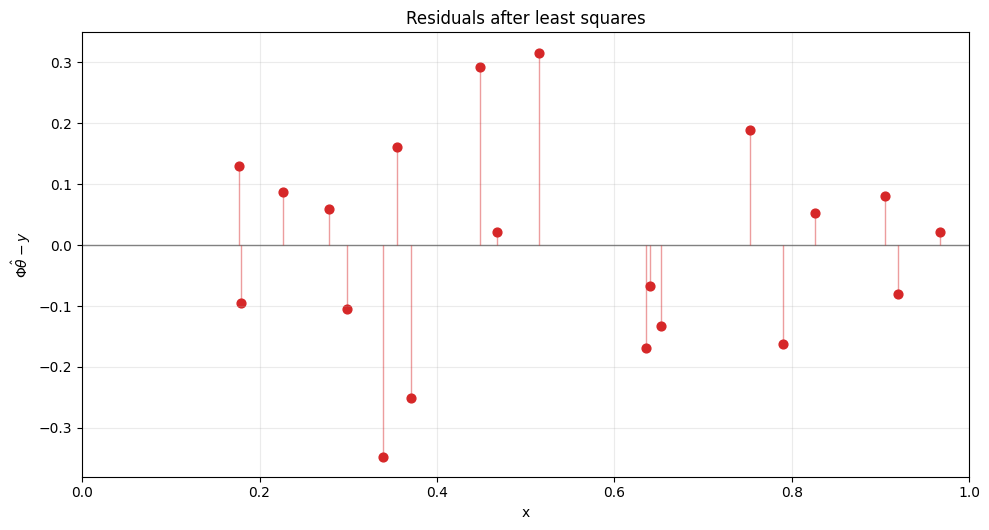

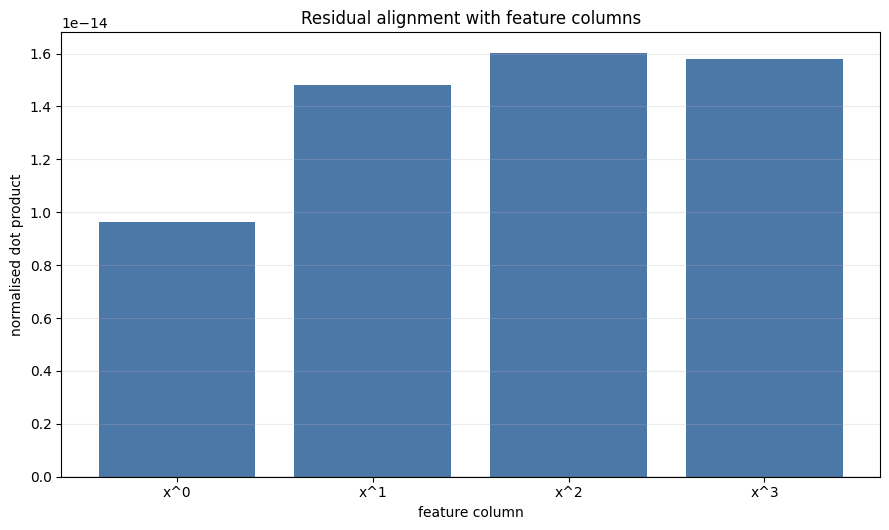

In [7]:
# Visualise the residual geometry behind the normal equations.
feature_names = [f"x^{idx}" for idx in range(Phi.shape[1])]
residual_norm = np.linalg.norm(residuals_lstsq)
feature_norms = np.linalg.norm(Phi, axis=0)
scaled_feature_alignment = feature_residual_dots / np.maximum(feature_norms * residual_norm, 1e-12)

fig_residuals, ax_residuals = plt.subplots(figsize=(10.0, 5.4))
ax_residuals.axhline(0.0, color="#555555", linewidth=1.0, alpha=0.7)
ax_residuals.scatter(x_train_opt, residuals_lstsq, s=40, color="#d62728")
ax_residuals.vlines(x_train_opt, 0.0, residuals_lstsq, color="#d62728", alpha=0.45, linewidth=1.0)
ax_residuals.set_title("Residuals after least squares")
ax_residuals.set_xlabel("x")
ax_residuals.set_ylabel(r"$\Phi\hat{\theta}-y$")
ax_residuals.set_xlim(0.0, 1.0)
ax_residuals.grid(alpha=0.25)
fig_residuals.tight_layout()
show_fig(fig_residuals)

fig_alignment, ax_alignment = plt.subplots(figsize=(9.0, 5.4))
ax_alignment.axhline(0.0, color="#555555", linewidth=1.0, alpha=0.7)
ax_alignment.bar(feature_names, scaled_feature_alignment, color="#4c78a8")
ax_alignment.set_title("Residual alignment with feature columns")
ax_alignment.set_xlabel("feature column")
ax_alignment.set_ylabel("normalised dot product")
ax_alignment.grid(axis="y", alpha=0.25)
fig_alignment.tight_layout()
show_fig(fig_alignment)


### Transition: objective versus solver

A selected point can be defined mathematically but reached computationally in different ways. This is why $\mathcal{O}$ includes both the objective and the solver.

| Part of $\mathcal{O}$ | Question it answers |
|---|---|
| Objective/loss | What counts as good? |
| Penalty/prior | What kinds of solutions are preferred? |
| Solver | How do we reach the selected solution? |
| Stopping or selection rule | Which point on a path do we keep? |

## Separate the Selector From the Solver

The equation

$$
\Phi^\top\Phi\theta=\Phi^\top y
$$

describes the selected least-squares point. It is not always the best computational route to that point.

Forming $\Phi^\top\Phi$ roughly squares the condition number of $\Phi$, which can magnify numerical error for high-degree monomial features. Production least-squares code commonly uses QR or singular-value decompositions through routines such as `np.linalg.lstsq`.

This distinction belongs inside $\mathcal{O}$. The objective says what should be selected; the numerical algorithm determines how reliably the intended selector is reached. In workshop language, the available features in $\mathcal{H}$ and the observed evidence $\mathcal{D}$ have not changed, but the implementation of the selection machinery matters.

Notebook 02 showed another way to improve conditioning: use different coordinates for the same polynomial function space, such as shifted Chebyshev features instead of raw monomial powers. That does not necessarily change which functions live in $\mathcal{H}$, but it can make the numerical search more stable because the feature columns are less redundant and less extreme over the input range.

For this notebook, keep the distinction simple: $\mathcal{H}$ says what functions are possible; the solver is part of $\mathcal{O}$ and says how reliably we reach the selected function under the chosen score.


## Change $\mathcal{O}$: Add a Penalty

Notebook 02 showed the unresolved problem: high-degree polynomial spaces contain many curves that finite data do not strongly constrain. Least squares can select a fragile explanation because it only asks for small residuals on $\mathcal{D}$.

One response is to change the optimization space. Keep the same evidence and the same hypothesis space, but add another preference to the score: alongside fitting $\mathcal{D}$, ask the selected curve to avoid large non-intercept parameters.

Intuitively, ridge says: "Fit the data, but do not spend huge coefficient values unless the reduction in residual error is worth it." The penalty does not remove flexible functions from $\mathcal{H}$. It changes which parts of $\mathcal{H}$ are cheap or expensive for the selector to choose.

$$
\mathcal{L}_{\mathcal{D},\lambda}(\theta) = \lVert \Phi \theta - y \rVert_2^2 + \lambda_{\mathrm{RSS}} \lVert R\theta \rVert_2^2,
$$

where $R = \operatorname{diag}(0,1,1,\ldots,1)$. Because this $R$ is diagonal with entries 0 or 1, $R^\top R = R$. The data term values small residuals. The penalty term values smaller non-intercept parameters. The selected solution is the compromise.

This is ridge regression, with closed-form solution:

$$
\hat{\theta}_\lambda = (\Phi^\top\Phi + \lambda_{\mathrm{RSS}} R^\top R)^{-1}\Phi^\top y.
$$

**Notation recap.** $\Phi$ is the observed-data feature matrix, $\theta$ is the parameter vector being selected, $R$ leaves the intercept alone and penalises the other coefficients, $\lambda_{\mathrm{RSS}}$ controls the penalty strength on an RSS-scaled objective, and $h_\theta$ is the function selected by that parameter vector.

The important modelling point is that ridge has not removed the degree-15 functions from $\mathcal{H}$. It has changed $\mathcal{O}$ by making some parameter choices more expensive before selecting $h_{\hat{\theta}_\lambda}$.

The subscript on $\lambda_{\mathrm{RSS}}$ is a scaling reminder. The cells here use:

$$
\text{RSS} + \lambda_{\mathrm{RSS}}\lVert R\theta\rVert_2^2.
$$

If you instead write the objective as:

$$
\text{MSE} + \lambda_{\mathrm{MSE}}\lVert R\theta\rVert_2^2,
$$

then the same solution uses:

$$
\lambda_{\mathrm{MSE}} = \frac{\lambda_{\mathrm{RSS}}}{n}.
$$

Multiplying the whole objective by a positive constant does not change the selected curve. Rescaling only the data term changes the number attached to `lambda`.

The next plot shows this score change directly in the two-parameter line case: as $\lambda_{\mathrm{RSS}}$ grows, the selected slope is pulled toward zero.

**Try these edits.** Before running the landscape cell, predict how the selected slope will change as `landscape_lambdas` grows. Then try `(0.0, 0.1, 100.0)` or `(0.0, 10.0, 1000.0)`. Which part of $\mathcal{H}+\mathcal{D}+\mathcal{O}\to s$ did you change?

### Optional probability side note: ridge as MAP

You can skip this side note without losing the optimization argument. It gives the same selection story in probability language.

If the residuals are assumed Gaussian, squared error is proportional to negative log-likelihood. If the non-intercept parameters are assumed to have a zero-centred Gaussian prior, the ridge penalty is proportional to negative log-prior.

Minimising squared error plus the ridge penalty is therefore equivalent to finding a maximum a posteriori estimate:

$$
\hat{\theta}_{\mathrm{MAP}}=\operatorname*{arg\,max}_\theta p(\mathcal{D}\mid \theta)p(\theta).
$$

The likelihood rewards compatibility with the observed data. The prior expresses a preference for smaller parameters before or beyond the current dataset. Ridge is therefore both a regularisation method and a probabilistic preference over parameters.

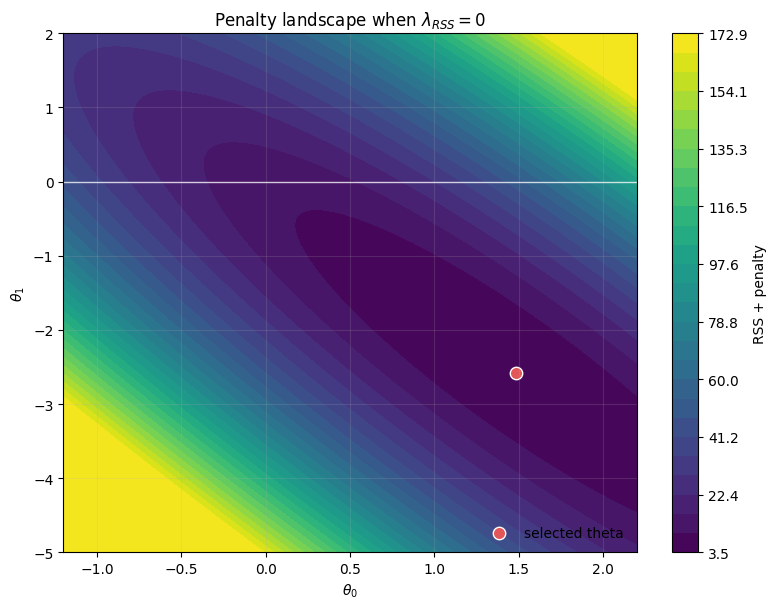

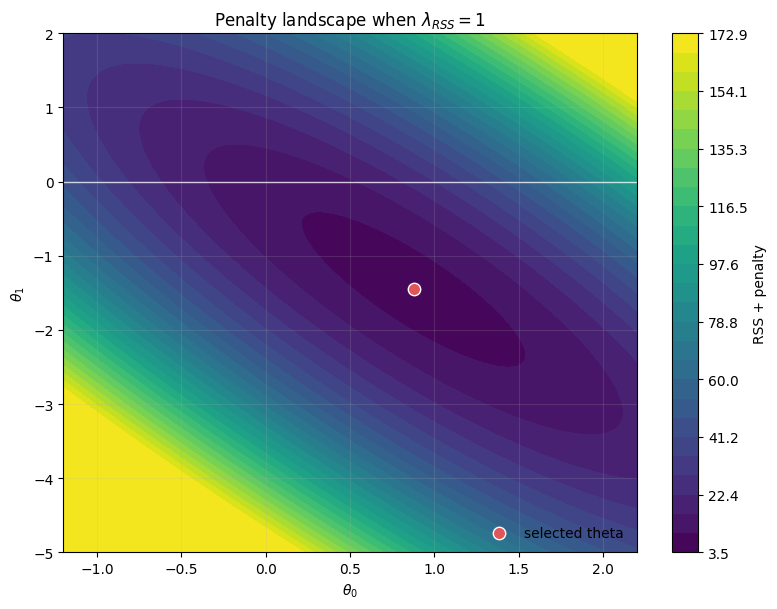

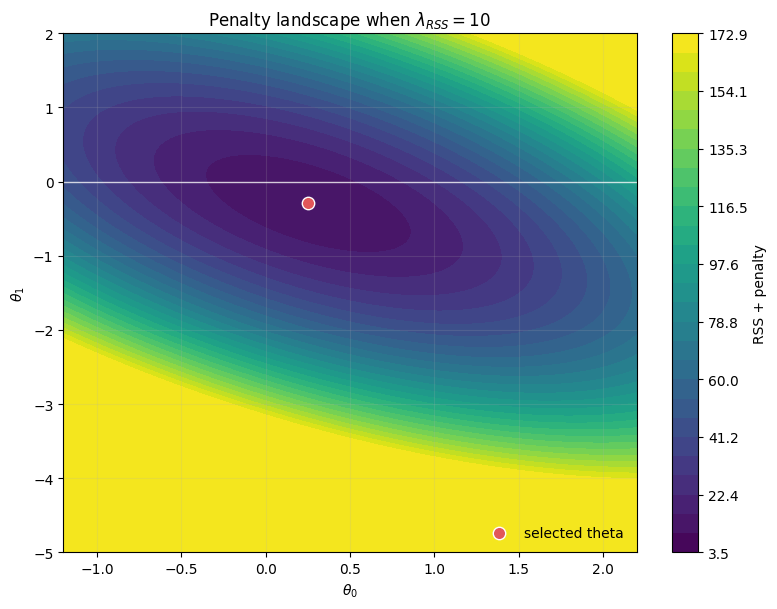

Selected degree-1 theta as the score changes
01. lambda_rss=0, theta_0=1.4847, theta_1=-2.5859, slope_abs=2.5859
02. lambda_rss=1.0000, theta_0=0.8772, theta_1=-1.4550, slope_abs=1.4550
03. lambda_rss=10.0000, theta_0=0.2540, theta_1=-0.2948, slope_abs=0.2948


In [8]:
# Show how the ridge penalty changes the objective landscape in a two-parameter model.
landscape_lambdas = (0.0, 1.0, 10.0)
theta0_values = np.linspace(-1.2, 2.2, 160)
theta1_values = np.linspace(-5.0, 2.0, 160)
Theta0, Theta1 = np.meshgrid(theta0_values, theta1_values)

landscape_surfaces = []
landscape_solutions = []
for lambda_reg in landscape_lambdas:
    objective = np.empty_like(Theta0)
    for row in range(Theta0.shape[0]):
        for col in range(Theta0.shape[1]):
            pred = Theta0[row, col] + Theta1[row, col] * x_train_opt
            rss = np.sum((y_train_opt - pred) ** 2)
            penalty = lambda_reg * Theta1[row, col] ** 2
            objective[row, col] = rss + penalty
    landscape_surfaces.append(objective)
    if lambda_reg == 0.0:
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=1)
    else:
        coeffs = models.fit_polynomial_ridge_map(x_train_opt, y_train_opt, degree=1, lambda_reg=lambda_reg)
    landscape_solutions.append(coeffs)

level_min = min(float(surface.min()) for surface in landscape_surfaces)
level_max = max(float(np.percentile(surface, 75)) for surface in landscape_surfaces)
levels = np.linspace(level_min, level_max, 28)

for lambda_reg, surface, coeffs in zip(landscape_lambdas, landscape_surfaces, landscape_solutions):
    fig, ax = plt.subplots(figsize=(8.0, 6.2))
    clipped = np.clip(surface, levels[0], levels[-1])
    contour = ax.contourf(Theta0, Theta1, clipped, levels=levels, cmap="viridis")
    ax.scatter(coeffs[0], coeffs[1], color="#e15759", s=80, edgecolor="white", label="selected theta")
    ax.axhline(0.0, color="white", linewidth=1.0, alpha=0.75)
    ax.set_title(rf"Penalty landscape when $\lambda_{{RSS}}={lambda_reg:g}$")
    ax.set_xlabel(r"$\theta_0$")
    ax.set_ylabel(r"$\theta_1$")
    ax.grid(alpha=0.18)
    ax.legend(frameon=False, loc="lower right")
    fig.colorbar(contour, ax=ax, label="RSS + penalty")
    fig.tight_layout()
    show_fig(fig)

print_rows(
    [
        {"lambda_rss": lam, "theta_0": coeffs[0], "theta_1": coeffs[1], "slope_abs": abs(coeffs[1])}
        for lam, coeffs in zip(landscape_lambdas, landscape_solutions)
    ],
    title="Selected degree-1 theta as the score changes",
)


## Follow a Selection Path

The two-parameter landscape shows the idea. Now return to the flexible degree-15 polynomial space from Notebook 02.

Keep the evidence and hypothesis space fixed. Vary only $\lambda_{\text{RSS}}$. Each value defines a different optimization space and therefore a different selected parameter vector. The path below is not a search over new model classes; it is a sequence of different selection rules applied to the same available family.

Read the table as a record of how the selector changes. Training MSE reports the data-fit part of the score, the coefficient norm reports the penalty target, and the system condition reports how the numerical problem changes as the penalty stabilises the coordinates.

### Before running: predict the ridge path

The next cell keeps $\mathcal{D}$ and $\mathcal{H}$ fixed and varies only $\lambda$. Fill this table before running.

| As $\lambda$ increases... | Prediction |
|---|---|
| Training MSE | |
| Coefficient norm | |
| Curve smoothness/stability | |
| Condition number | |


In [9]:
# Keep the fitting data and degree fixed, then change only the regularisation strength.
ridge_degree = 15
lambdas = (0.0, 1e-4, 1e-2, 1.0, 100.0)
ridge_rows = []
ridge_fits = {}
Phi_ridge = models.polynomial_features(x_train_opt, degree=ridge_degree)
R = np.eye(ridge_degree + 1)
R[0, 0] = 0.0

for lambda_reg in lambdas:
    if lambda_reg == 0.0:
        # Use the stable least-squares path for the unregularised baseline.
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=ridge_degree)
    else:
        coeffs = models.fit_polynomial_ridge_map(
            x_train_opt,
            y_train_opt,
            degree=ridge_degree,
            lambda_reg=lambda_reg,
        )
    train_pred = models.predict_polynomial(x_train_opt, coeffs)
    residual_sum_squares = float(np.sum((y_train_opt - train_pred) ** 2))
    penalty = float(lambda_reg * np.sum(coeffs[1:] ** 2))
    system_matrix = Phi_ridge.T @ Phi_ridge + lambda_reg * R
    ridge_rows.append(
        {
            "lambda_rss": lambda_reg,
            "lambda_mse_equiv": lambda_reg / len(y_train_opt),
            "train_mse": metrics.mse(y_train_opt, train_pred),
            "data_sse": residual_sum_squares,
            "penalty": penalty,
            "penalized_coef_norm": np.linalg.norm(coeffs[1:]),
            "system_condition": np.linalg.cond(system_matrix),
        }
    )
    ridge_fits[lambda_reg] = coeffs

print_rows(ridge_rows, digits=5, title=f"Degree {ridge_degree} with different objective penalties")

Degree 15 with different objective penalties
01. lambda_rss=0, lambda_mse_equiv=0, train_mse=0.00977, data_sse=0.19534, penalty=0, penalized_coef_norm=5.14e+11, system_condition=8.59e+17
02. lambda_rss=0.00010, lambda_mse_equiv=5.00e-06, train_mse=0.03020, data_sse=0.60392, penalty=0.04911, penalized_coef_norm=22.16019, system_condition=3.82e+05
03. lambda_rss=0.01000, lambda_mse_equiv=0.00050, train_mse=0.04459, data_sse=0.89182, penalty=0.15505, penalized_coef_norm=3.93759, system_condition=3825.05959
04. lambda_rss=1.00000, lambda_mse_equiv=0.05000, train_mse=0.15341, data_sse=3.06824, penalty=2.09421, penalized_coef_norm=1.44714, system_condition=39.62253
05. lambda_rss=100.00000, lambda_mse_equiv=5.00000, train_mse=0.56059, data_sse=11.21180, penalty=0.43762, penalized_coef_norm=0.06615, system_condition=7.23927


## Preview the Regularisation Trade-off

The table above shows a few selected $\lambda_{\mathrm{RSS}}$ values. The next cell uses a denser grid of penalty strengths so the path is easier to see.

Read the figure as three linked views of the same change to $\mathcal{O}$:

1. the left panel shows several selected curves from the same $\mathcal{H}$;
2. the top-right panel compares training MSE with a held-out check sample; and
3. the bottom-right panel shows the non-intercept coefficient norm that ridge is trying to shrink.

The held-out sample is a Notebook 04 preview only. It is not used by the optimizer and it is not cross-validation. Its role here is to make one limitation visible: winning the training objective is not the same as travelling well to fresh evidence.


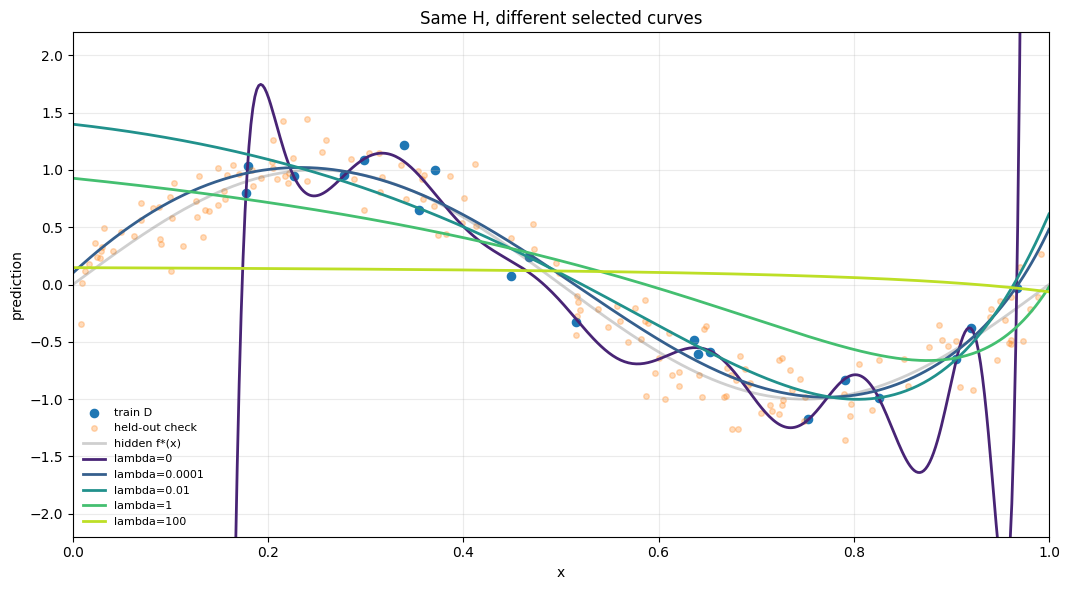

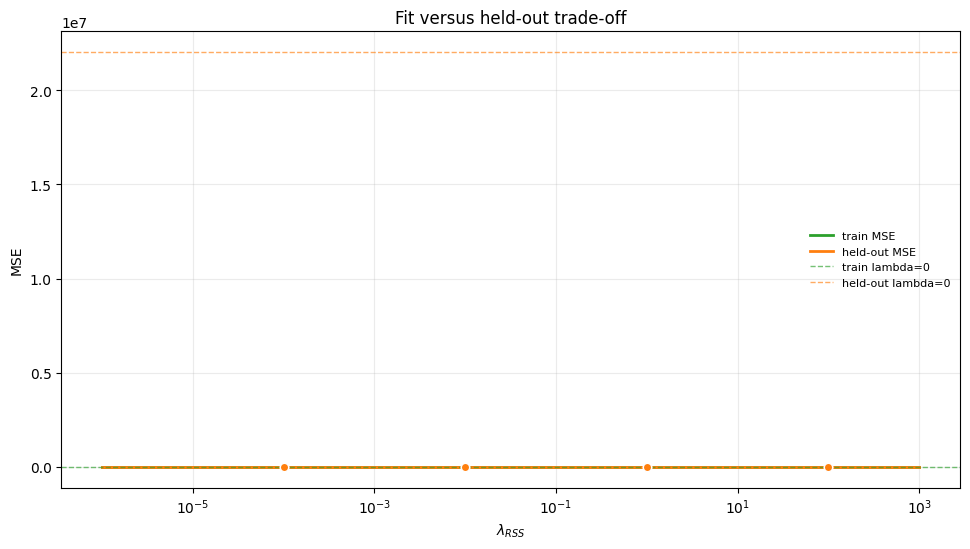

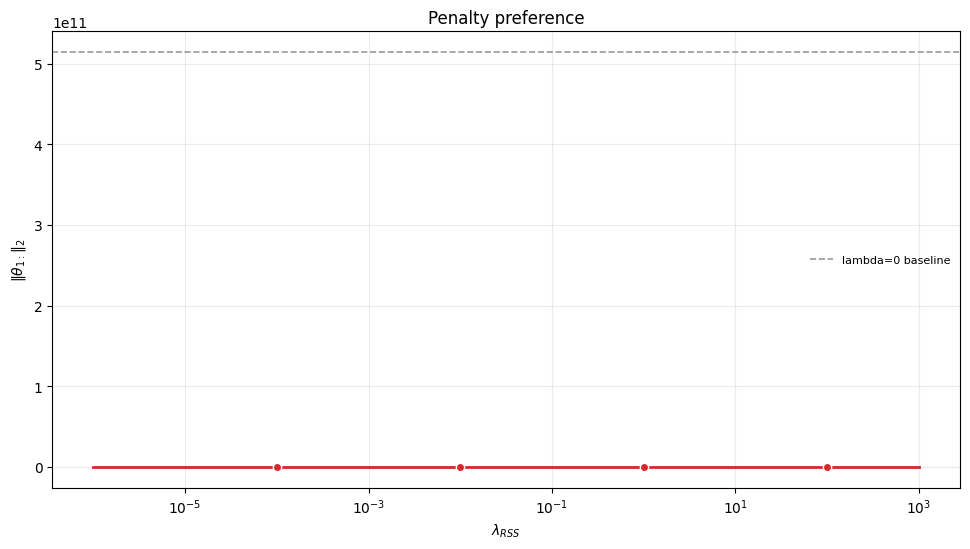

Held-out preview of the regularisation trade-off
01. best_lambda_by_heldout_mse=0.00007, train_mse_at_best=0.02946, heldout_mse_at_best=0.04878, lambda_0_train_mse=0.00977, lambda_0_heldout_mse=2.20e+07


In [10]:
# Visualise selected curves and the train/held-out trade-off across lambda values.
# The held-out sample previews Notebook 04: it is not used by the optimizer.
x_test_opt, y_test_opt = data.make_regression_data(
    n=160,
    noise_std=noise_std,
    seed=seed + 1,
    sampling=sampling,
)

path_lambdas = np.r_[0.0, np.logspace(-6, 3, 140)]
path_train_mse = []
path_test_mse = []
path_coef_norm = []
path_data_sse = []
path_penalty = []
path_coeffs = {}

for lambda_reg in path_lambdas:
    if lambda_reg == 0.0:
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=ridge_degree)
    else:
        coeffs = models.fit_polynomial_ridge_map(
            x_train_opt,
            y_train_opt,
            degree=ridge_degree,
            lambda_reg=lambda_reg,
        )
    train_pred = models.predict_polynomial(x_train_opt, coeffs)
    test_pred = models.predict_polynomial(x_test_opt, coeffs)
    data_sse = float(np.sum((y_train_opt - train_pred) ** 2))
    coef_norm = float(np.linalg.norm(coeffs[1:]))
    path_train_mse.append(metrics.mse(y_train_opt, train_pred))
    path_test_mse.append(metrics.mse(y_test_opt, test_pred))
    path_coef_norm.append(coef_norm)
    path_data_sse.append(data_sse)
    path_penalty.append(float(lambda_reg * coef_norm**2))
    path_coeffs[float(lambda_reg)] = coeffs

positive_mask = path_lambdas > 0
positive_lambdas = path_lambdas[positive_mask]
train_curve = np.array(path_train_mse)[positive_mask]
test_curve = np.array(path_test_mse)[positive_mask]
norm_curve = np.array(path_coef_norm)[positive_mask]
selected_positive_lambdas = [row["lambda_rss"] for row in ridge_rows if row["lambda_rss"] > 0]
selected_train_mse = [row["train_mse"] for row in ridge_rows if row["lambda_rss"] > 0]
selected_test_mse = [
    metrics.mse(y_test_opt, models.predict_polynomial(x_test_opt, ridge_fits[row["lambda_rss"]]))
    for row in ridge_rows
    if row["lambda_rss"] > 0
]
selected_norms = [row["penalized_coef_norm"] for row in ridge_rows if row["lambda_rss"] > 0]

fig_curve, ax_curve = plt.subplots(figsize=(10.8, 6.0))
ax_curve.scatter(x_train_opt, y_train_opt, s=35, color="#1f77b4", label="train D")
ax_curve.scatter(x_test_opt, y_test_opt, s=16, color="#ff7f0e", alpha=0.28, label="held-out check")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(lambdas)))
for color, lambda_reg in zip(colors, lambdas):
    curve = models.predict_polynomial(x_grid, ridge_fits[lambda_reg])
    ax_curve.plot(x_grid, curve, color=color, linewidth=2.0, label=f"lambda={lambda_reg:g}")
ax_curve.set_title("Same H, different selected curves")
ax_curve.set_xlabel("x")
ax_curve.set_ylabel("prediction")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.2, 2.2)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_mse, ax_mse = plt.subplots(figsize=(9.8, 5.6))
ax_mse.semilogx(positive_lambdas, train_curve, color="#2ca02c", linewidth=2.0, label="train MSE")
ax_mse.semilogx(positive_lambdas, test_curve, color="#ff7f0e", linewidth=2.0, label="held-out MSE")
ax_mse.scatter(selected_positive_lambdas, selected_train_mse, color="#2ca02c", edgecolor="white", zorder=3)
ax_mse.scatter(selected_positive_lambdas, selected_test_mse, color="#ff7f0e", edgecolor="white", zorder=3)
ax_mse.axhline(path_train_mse[0], color="#2ca02c", linestyle="--", linewidth=1.0, alpha=0.65, label="train lambda=0")
ax_mse.axhline(path_test_mse[0], color="#ff7f0e", linestyle="--", linewidth=1.0, alpha=0.65, label="held-out lambda=0")
ax_mse.set_title("Fit versus held-out trade-off")
ax_mse.set_xlabel(r"$\lambda_{RSS}$")
ax_mse.set_ylabel("MSE")
ax_mse.grid(alpha=0.25)
ax_mse.legend(frameon=False, fontsize=8)
fig_mse.tight_layout()
show_fig(fig_mse)

fig_norm, ax_norm = plt.subplots(figsize=(9.8, 5.6))
ax_norm.semilogx(positive_lambdas, norm_curve, color="#d62728", linewidth=2.0)
ax_norm.scatter(selected_positive_lambdas, selected_norms, color="#d62728", edgecolor="white", zorder=3)
ax_norm.axhline(path_coef_norm[0], color="#999999", linestyle="--", linewidth=1.2, label="lambda=0 baseline")
ax_norm.set_title("Penalty preference")
ax_norm.set_xlabel(r"$\lambda_{RSS}$")
ax_norm.set_ylabel(r"$\Vert\theta_{1:}\Vert_2$")
ax_norm.grid(alpha=0.25)
ax_norm.legend(frameon=False, fontsize=8)
fig_norm.tight_layout()
show_fig(fig_norm)

best_idx = int(np.argmin(path_test_mse))
print_rows(
    [
        {
            "best_lambda_by_heldout_mse": path_lambdas[best_idx],
            "train_mse_at_best": path_train_mse[best_idx],
            "heldout_mse_at_best": path_test_mse[best_idx],
            "lambda_0_train_mse": path_train_mse[0],
            "lambda_0_heldout_mse": path_test_mse[0],
        }
    ],
    digits=5,
    title="Held-out preview of the regularisation trade-off",
)


### After running: diagnose the regularisation trade-off

The ridge path shows a sequence of selected solutions from the same raw hypothesis space.

- Low $\lambda$ values prioritise fitting the observed rows.
- High $\lambda$ values make large coefficients expensive.
- The selected curve moves because the optimization space changed, not because the data or model family changed.

**Repack.** Regularisation is a solution-selection preference. It is one way to control what parts of a rich hypothesis space are cheap or expensive for the optimizer to choose.

## Summary: What $\mathcal{O}$ Adds and What It Cannot Prove

The observations stayed fixed. The degree-15 hypothesis space stayed available. The selected function changed because the optimization space changed.

1. **Loss defines what counts as fit.** MSE says that smaller squared residuals on $\mathcal{D}$ are better. A different loss would value different kinds of errors and could select a different solution from the same $\mathcal{H}$.

2. **Minimisation turns scores into a selected solution.** Least squares is not just a formula; it is a rule for choosing the candidate with the smallest training score. The normal-equation check showed the geometry of that choice.

3. **Penalties add preferences.** Ridge still values fit to $\mathcal{D}$, but it also makes large non-intercept coefficients expensive. Increasing $\lambda$ moves the selected solution toward smaller parameter norms, usually at the cost of higher training error.

4. **Solvers implement the selector.** For squared loss and ridge, the objective is quadratic and has a closed-form solution. In later models, the same conceptual role is often played by iterative algorithms. The algorithm matters because it determines how the intended selection rule is reached.

5. **Held-out checks are not part of this selector.** The final held-out plot is a Notebook 04 preview only. The held-out sample is not used by the optimizer and it is not a cross-validation protocol. It is included here to make one consequence visible: a selector that wins on training loss is not automatically the selector that looks best on fresh evidence.

That is the limit of $\mathcal{O}$. It can choose a solution from $\mathcal{H}$ using $\mathcal{D}$, and it can encode useful preferences such as smoothness or smaller coefficients. It cannot, by itself, prove that the selected solution belongs in the solution space $\mathcal{S}$ we would trust for future use. Notebook 04 introduces validation and test evidence and asks where the learned function is actually constrained.


## Optimization-space diagnostic checklist

When a selected solution looks surprising, ask:

| Diagnostic | Question |
|---|---|
| Loss | What errors does the objective reward or punish? |
| Penalty/prior | What solutions are made cheaper or more expensive? |
| Solver | Did the numerical method reliably reach the intended solution? |
| Scaling/conditioning | Is the coordinate system making selection unstable? |
| Validation use | Was fresh evidence used to choose settings, or only to check them? |

**Notebook takeaway.** $\mathcal{O}$ selects a solution from $\mathcal{H}$ using $\mathcal{D}$. It does not by itself prove that the selected solution will generalise.

## Bridge to Notebook 04

We now have the three ingredients that produce a fitted rule: available hypotheses $h_\theta\in\mathcal{H}$, observed evidence $\mathcal{D}$, and an optimization space $\mathcal{O}$ that chooses a parameter value $\hat{\theta}\in\Theta$.

Notebook 03 made selection explicit:

$$
(\mathcal{H},\mathcal{D},\mathcal{O}) \longmapsto s.
$$

But selection is not the same as trust. A curve can be the best candidate under the chosen score and still fail in regions that were sparse, noisy, or held out from selection.

Notebook 04 changes the question from "which candidate did the selector choose?" to "where should that selected rule travel?" That is the generalisation question.

## References

A compact set of checked references for convex quadratic objectives, numerical least squares, ridge regression, and the MAP interpretation.

- Boyd, S., & Vandenberghe, L. (2004). [*Convex Optimization*](https://www.cambridge.org/highereducation/books/convex-optimization/17D2FAA54F641A2F62C7CCD01DFA97C4). Convex objectives, quadratic geometry, and uniqueness of minimisers.
- Björck, Å. (1996). [*Numerical Methods for Least Squares Problems*](https://epubs.siam.org/doi/10.1137/1.9781611971484). Least-squares computation, normal equations, QR/SVD methods, rank deficiency, and regularisation.
- Hoerl, A. E., & Kennard, R. W. (1970). [*Ridge Regression: Biased Estimation for Nonorthogonal Problems*](https://www.tandfonline.com/doi/abs/10.1080/00401706.1970.10488634), *Technometrics*, 12(1), 55-67. Original ridge-regression motivation for stabilising nonorthogonal regression problems.
- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Gaussian likelihoods, Gaussian parameter priors, and MAP estimation.
